Training Text Classification Model...
--- Model Evaluation ---
Accuracy: 0.7642

Classification Report:


/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier,

              precision    recall  f1-score   support

   Defaulted       0.00      0.00      0.00       841
Late Payment       0.00      0.00      0.00      1517
Paid On Time       0.76      1.00      0.87      7642

    accuracy                           0.76     10000
   macro avg       0.25      0.33      0.29     10000
weighted avg       0.58      0.76      0.66     10000



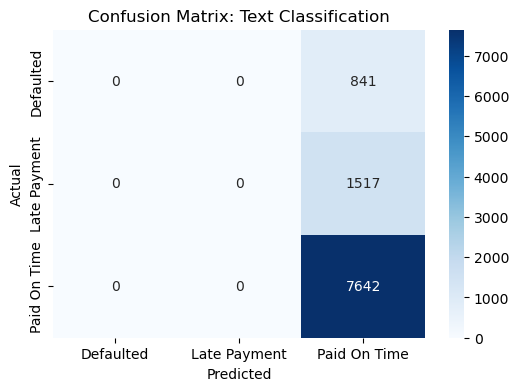

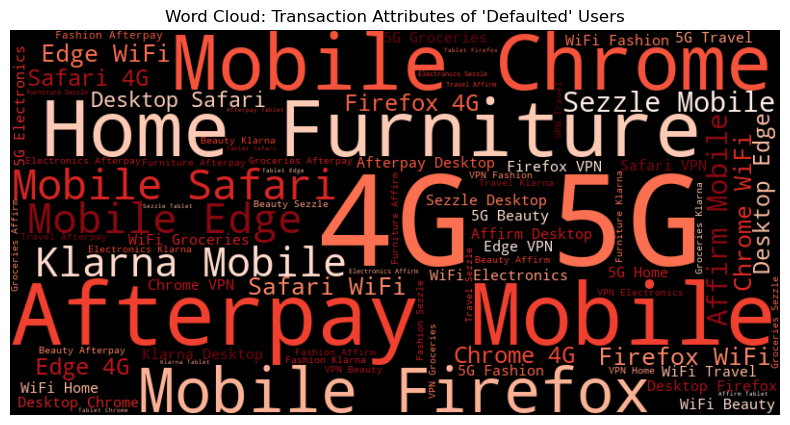

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from wordcloud import WordCloud

# ==========================================
# 1. DATA LOADING & PREPROCESSING
# ==========================================
# Load the v2 dataset which contains more categorical features
df = pd.read_csv('bnpl_dataset_v2.csv')

# Synthesizing a 'Text' column for Text Analytics
# We combine categorical transaction attributes into a single text document per user
df['Transaction_Text'] = (df['Purchase_Category'] + ' ' + 
                          df['BNPL_Provider'] + ' ' + 
                          df['Device_Type'] + ' ' + 
                          df['Browser'] + ' ' + 
                          df['Connection_Type'])

# Drop any potential nulls in our text column
df = df.dropna(subset=['Transaction_Text', 'Repayment_Status'])

# ==========================================
# 2. TEXT ANALYTICS MODELING (CLASSIFICATION)
# ==========================================
X = df['Transaction_Text']
y = df['Repayment_Status'] # Target: "Paid On Time" vs "Defaulted"

# Split data: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Convert text data to TF-IDF features
vectorizer = TfidfVectorizer(max_features=1000)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# Initialize and train Logistic Regression model
print("Training Text Classification Model...")
model = LogisticRegression(max_iter=1000)
model.fit(X_train_vec, y_train)

# ==========================================
# 3. EVALUATION METRICS
# ==========================================
y_pred = model.predict(X_test_vec)

print("--- Model Evaluation ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# ==========================================
# 4. VISUALIZATION & INSIGHTS
# ==========================================
# A. Confusion Matrix
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=model.classes_, yticklabels=model.classes_)
plt.title('Confusion Matrix: Text Classification')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# B. Word Cloud for 'Defaulted' Transactions
defaulted_text = " ".join(text for text in df[df['Repayment_Status'] == 'Defaulted']['Transaction_Text'])
wordcloud_default = WordCloud(width=800, height=400, background_color='black', colormap='Reds').generate(defaulted_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_default, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud: Transaction Attributes of 'Defaulted' Users")
plt.show()

In [4]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets
from IPython.display import display, clear_output, HTML, Markdown

# ==========================================
# 1. LOAD DATA & TRAIN MODEL (Background)
# ==========================================
df = pd.read_csv('bnpl_dataset_v2.csv')

# Combine attributes into a single text profile
df['Transaction_Text'] = df['Purchase_Category'] + ' ' + df['BNPL_Provider'] + ' ' + df['Device_Type'] + ' ' + df['Browser'] + ' ' + df['Connection_Type']

df = df.dropna(subset=['Transaction_Text', 'Repayment_Status'])

X = df['Transaction_Text']
y = df['Repayment_Status']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

vectorizer = TfidfVectorizer()
X_train_vec = vectorizer.fit_transform(X_train)
model = LogisticRegression(max_iter=1000)
model.fit(X_train_vec, y_train)

# Define our color palette for the 3 categories
STATUS_COLORS = {
    'Paid On Time': '#28a745',  # Green
    'Late Payment': '#ffc107',  # Yellow/Orange
    'Defaulted': '#dc3545'      # Red
}

# ==========================================
# 2. BUILD INTERACTIVE WIDGETS
# ==========================================

# --- TAB 1: Dynamic Data Explorer ---
feature_dropdown = widgets.Dropdown(options=['BNPL_Provider', 'Device_Type', 'Browser', 'Purchase_Category', 'Connection_Type'], description='Analyze By:', style={'description_width': 'initial'})
out_explore = widgets.Output()

def update_explore_chart(change):
    with out_explore:
        clear_output(wait=True)
        feature = feature_dropdown.value
        plt.figure(figsize=(10, 4))
        
        # Updated to use the 3-color STATUS_COLORS dictionary
        sns.countplot(data=df, x=feature, hue='Repayment_Status', palette=STATUS_COLORS)
        
        plt.title(f'Repayment Status Breakdown by {feature}', fontsize=14, fontweight='bold')
        plt.xlabel(feature.replace('_', ' '))
        plt.ylabel('Number of Transactions')
        plt.xticks(rotation=15)
        plt.legend(title='Status')
        plt.tight_layout()
        plt.show()

# Observe changes so chart updates automatically when dropdown changes
feature_dropdown.observe(update_explore_chart, names='value')

tab1_ui = widgets.VBox([
    widgets.HTML("<h4>📊 Select a transaction feature to see how it affects repayment behavior:</h4>"),
    feature_dropdown,
    out_explore
])

# Trigger the first chart to draw immediately
with out_explore:
    update_explore_chart(None)


# --- TAB 2: Interactive Word Cloud ---
status_dropdown = widgets.Dropdown(options=df['Repayment_Status'].unique(), description='Status:')
generate_btn = widgets.Button(description='Generate Cloud', button_style='info', icon='cloud')
out_wc = widgets.Output()

def on_generate_click(b):
    with out_wc:
        clear_output(wait=True) 
        status = status_dropdown.value
        text_data = " ".join(df[df['Repayment_Status'] == status]['Transaction_Text'])
        wc = WordCloud(width=800, height=350, background_color='white', colormap='viridis').generate(text_data)
        
        plt.figure(figsize=(10, 4.5))
        plt.imshow(wc, interpolation='bilinear')
        plt.axis('off')
        plt.title(f"Most Frequent Profile Keywords for '{status}'", fontsize=14)
        plt.tight_layout()
        plt.show()

generate_btn.on_click(on_generate_click)
tab2_ui = widgets.VBox([
    widgets.HTML("<h4>☁️ Visualize the most common terms in transaction text profiles:</h4>"),
    widgets.HBox([status_dropdown, generate_btn]), 
    out_wc
])


# --- TAB 3: Visual Text Predictor ---
cat_drop = widgets.Dropdown(options=df['Purchase_Category'].unique(), description='Category:')
prov_drop = widgets.Dropdown(options=df['BNPL_Provider'].unique(), description='Provider:')
dev_drop = widgets.Dropdown(options=df['Device_Type'].unique(), description='Device:')
brow_drop = widgets.Dropdown(options=df['Browser'].unique(), description='Browser:')
conn_drop = widgets.Dropdown(options=df['Connection_Type'].unique(), description='Network:')

predict_btn = widgets.Button(description='Run Prediction', button_style='success', icon='check', layout=widgets.Layout(width='95%'))
out_pred = widgets.Output()

def on_predict_click(b):
    with out_pred:
        clear_output()
        user_text = f"{cat_drop.value} {prov_drop.value} {dev_drop.value} {brow_drop.value} {conn_drop.value}"
        
        vec_input = vectorizer.transform([user_text])
        prediction = model.predict(vec_input)[0]
        probs = model.predict_proba(vec_input)[0]
        prob_dict = dict(zip(model.classes_, probs))
        
        display(Markdown(f"**Synthesized Profile String:** `{user_text}`"))
        
        # Handling all 3 potential text outputs dynamically
        pred_color = STATUS_COLORS.get(prediction, '#000000')
        icon = "✅" if prediction == "Paid On Time" else ("⚠️" if prediction == "Late Payment" else "❌")
        display(Markdown(f"### {icon} Prediction: <span style='color:{pred_color}'>**{prediction}**</span>"))
            
        html_bars = "<h4>Model Confidence:</h4>"
        for cls, prob in prob_dict.items():
            color = STATUS_COLORS.get(cls, '#6c757d')
            width = prob * 100
            html_bars += f"""
            <div style="margin-bottom: 8px; font-family: Arial;">
                <div style="display: flex; justify-content: space-between; width: 300px;">
                    <span><b>{cls}</b></span>
                    <span>{width:.1f}%</span>
                </div>
                <div style="width: 300px; background-color: #e9ecef; border-radius: 4px; overflow: hidden;">
                    <div style="width: {width}%; background-color: {color}; height: 12px;"></div>
                </div>
            </div>
            """
        display(HTML(html_bars))

predict_btn.on_click(on_predict_click)

controls_box = widgets.VBox([cat_drop, prov_drop, dev_drop, brow_drop, conn_drop, widgets.HTML("<br>"), predict_btn], layout=widgets.Layout(width='300px'))
tab3_ui = widgets.VBox([
    widgets.HTML("<h4>🤖 Build a user profile to predict their repayment behavior:</h4>"),
    widgets.HBox([controls_box, out_pred])
])


# ==========================================
# 3. ASSEMBLE DASHBOARD TABS
# ==========================================
tabs = widgets.Tab(children=[tab1_ui, tab2_ui, tab3_ui])
tabs.set_title(0, '📊 Data Explorer')
tabs.set_title(1, '☁️ Word Clouds')
tabs.set_title(2, '🤖 Smart Predictor')

# Display everything
display(HTML("<h2 style='color: #2E86C1; border-bottom: 2px solid #2E86C1; padding-bottom: 5px;'>💳 Advanced BNPL Text Analytics Dashboard</h2>"))
display(tabs)